# Binary Response Motivation

**Project question:** Why is ordinary least squares not a coherent probability model for churn?

By the end of this notebook, you should be able to:

- identify impossible linear-probability predictions
- connect probability, odds, log-odds, and the logistic curve
- state what logistic regression fixes and what it does not prove

This notebook is a demonstration, not a homework assignment. The data are
synthetic and were generated for teaching; numerical results should not be
interpreted as evidence about a real organization or population.

In [1]:

from lite_setup import ensure_packages
await ensure_packages()

Using the current Python environment.


In [2]:

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
if not DATA.exists():
    raise FileNotFoundError("Open this notebook from the JupyterLite files root so data/ is available.")

In [3]:
import statsmodels.formula.api as smf
from scipy.special import expit

In [4]:
df = pd.read_csv(DATA / 'simulated_churn.csv')
df.head()

,customer_id,churn,tenure_months,monthly_charge,support_tickets,usage_gb,contract,autopay,satisfaction
0,C0001,0,26,51.01,1,93.0,one_year,no,5.1
1,C0002,0,8,80.90,1,90.6,month_to_month,no,7.7
2,C0003,0,11,37.50,0,112.5,month_to_month,yes,4.5
3,C0004,0,9,75.34,1,117.8,one_year,yes,6.5
4,C0005,0,4,40.52,1,79.0,two_year,no,7.8


Text(0.5, 1.0, 'Binary response: churn')

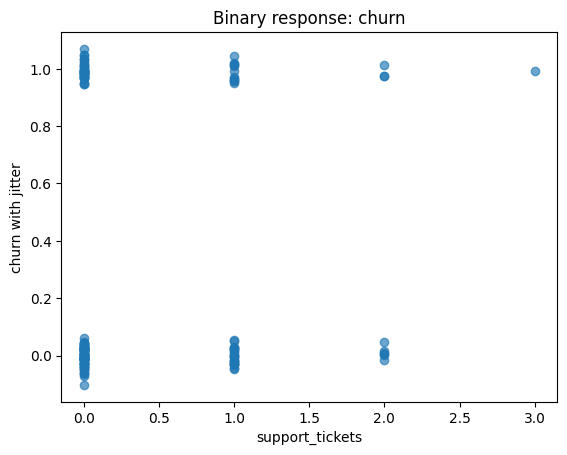

In [5]:
sample = df.sample(160, random_state=4031)
jitter = np.random.default_rng(4031).normal(0, 0.03, size=len(sample))
plt.scatter(sample['support_tickets'], sample['churn'] + jitter, alpha=0.65)
plt.xlabel('support_tickets')
plt.ylabel('churn with jitter')
plt.title('Binary response: churn')

In [6]:
ols = smf.ols('churn ~ tenure_months + monthly_charge + support_tickets + usage_gb + satisfaction', data=df).fit()
linear_probability = ols.predict(df)
pd.Series({
    'minimum_prediction': linear_probability.min(),
    'maximum_prediction': linear_probability.max(),
    'predictions_below_0': int((linear_probability < 0).sum()),
    'predictions_above_1': int((linear_probability > 1).sum()),
})

minimum_prediction     -0.395943
maximum_prediction      1.017345
predictions_below_0    19.000000
predictions_above_1     1.000000
dtype: float64

**Interpretation:** OLS can be a descriptive linear-probability approximation, but these fitted values show that it does not constrain predictions to the probability interval. Its constant-error-variance assumption also conflicts with a Bernoulli response.

For probability $p$, the odds are $p/(1-p)$ and the log-odds are $\log[p/(1-p)]$. Logistic regression makes the log-odds linear, then maps the linear predictor back to $(0,1)$ with $p=1/(1+e^{-\eta})$.

Text(0.5, 1.0, 'Logistic curve maps real numbers to probabilities')

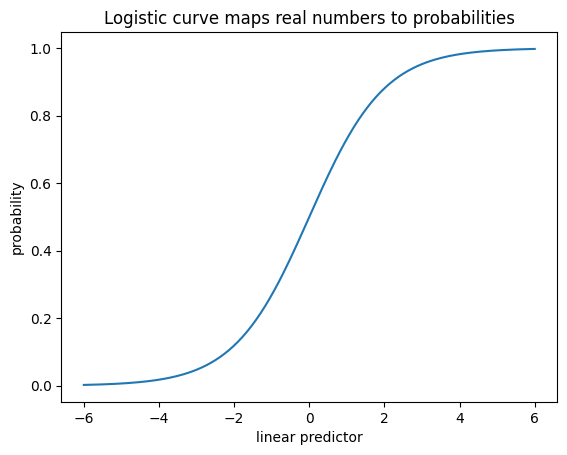

In [7]:
x = np.linspace(-6, 6, 200)
plt.plot(x, expit(x))
plt.xlabel('linear predictor')
plt.ylabel('probability')
plt.title('Logistic curve maps real numbers to probabilities')

**Takeaway:** Logistic regression supplies a coherent conditional-probability model. It does not by itself establish causality, calibration on future populations, or an appropriate action threshold.